### **Essay Workflow - LLM Based Parallel workflow**

In [6]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = ChatGoogleGenerativeAI(
    model = "gemini-3.6-flash"
)


print(f"[INFO] Model : {model.model} Loaded Successfully!")

[INFO] Model : gemini-3.6-flash Loaded Successfully!


### **Essay State**

In [7]:
from typing import TypedDict, Annotated, List
from operator import add
from pydantic import BaseModel, Field

class EssayState(TypedDict):
    essay : str
    lang_feedback : str
    als_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_scores : Annotated[List[int], add]
    avg_score : float


### **Creating Evaluation Schema for structured output**

In [8]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description="Detailed Feedback for the essay under 100 words.")
    score:int = Field(description="Score out of 10.", le=10, ge=0)

In [9]:
structured_model = model.with_structured_output(EvaluationSchema)
structured_model

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}, output_version=None, profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'medium'}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.6-flash', temperature=None, client=<google.genai.client.Client object at 0x

In [10]:
essay = """# Impact of AI on the Upcoming Computer Science Engineers

Artificial Intelligence (AI) is rapidly transforming the world and has become an important part of Computer Science. For upcoming Computer Science engineers, AI will bring both exciting opportunities and new challenges. It is changing how software is developed, how problems are solved, and what skills engineers need to succeed.

One of the major impacts of AI is its role in software development. AI-powered tools can help engineers write code, find errors, test programs, and understand complex concepts. This can make development faster and more efficient. However, AI does not eliminate the need for programming knowledge. Future engineers must understand the fundamentals of programming and algorithms so that they can check, improve, and correctly use AI-generated solutions.

AI is also changing the skills required in the technology industry. Along with programming, upcoming engineers will benefit from knowledge of machine learning, data science, cloud computing, cybersecurity, and AI technologies. At the same time, human skills such as creativity, communication, critical thinking, and problem-solving will become even more important because AI cannot completely replace human judgment and creativity.

Another important impact is automation. AI can perform many repetitive tasks, which may reduce the demand for some traditional jobs. Therefore, Computer Science engineers must continuously learn new technologies and update their skills. Instead of seeing AI only as a competitor, engineers should learn to use it as a powerful assistant that improves their productivity.

AI also creates ethical responsibilities. Engineers working with AI must consider privacy, security, fairness, and the possibility of biased or incorrect results. Responsible development will be essential as AI becomes more involved in everyday life.

In conclusion, AI will greatly influence the future of Computer Science engineering. It will automate some tasks while creating new opportunities and fields of work. The successful engineers of the future will be those who combine strong technical knowledge with creativity, adaptability, critical thinking, and responsible use of AI. AI should therefore be viewed not as a threat, but as a powerful tool that can help the next generation of engineers build a smarter future.
"""

In [11]:
prompt = f"Evaluate the langauage quality of the following essay and provide a feedback and assign a score out of 10.\n{essay}"

In [12]:
result = structured_model.invoke(prompt)

In [13]:
result.feedback

'The language quality of the essay is excellent. It demonstrates clear sentence structure, correct grammar, and precise vocabulary. Paragraph transitions are smooth, creating a logical flow of ideas throughout the text. The tone is formal and appropriate for a technical discussion. To improve further, the author could incorporate more varied sentence structures and advanced domain-specific phrasing, but overall, it is well-written, articulate, and very easy to read.'

In [14]:
result.score

9

### **Implementing the Workflow**

#### **Node 1 : Evaluate Language Node**

In [20]:
def eval_language(state: EssayState):
    prompt = f"Evaluate the langauage quality of the following essay and provide a feedback and assign a score out of 10.\n{state["essay"]}"

    response = structured_model.invoke(prompt)
    return {
        "lang_feedback" : response.feedback,
        "individual_scores" : [response.score]
    }


### **Node 2 : Evaluate Analysis Node**

In [19]:
def eval_analysis(state: EssayState):
    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10.\n{state["essay"]}"

    response = structured_model.invoke(prompt)
    return {
        "als_feedback" : response.feedback,
        "individual_scores" : [response.score]
    }


### **Node 3: Evaluate Clarity Node**

In [21]:
def eval_clarity(state: EssayState):
    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10.\n{state["essay"]}"

    response = structured_model.invoke(prompt)
    return {
        "clarity_feedback" : response.feedback,
        "individual_scores" : [response.score]
    }

### **Node 4 : Final Evaluation Node**

In [24]:
def final_eval(state: EssayState):
    prompt = f"""
    Based on the folowing feedbacks create a summarized feedback\n
    langauge feedback - {state['lang_feedback']}.\n
    depth of analysis feedback - {state['als_feedback']}.\n
    clarity of thought feedback - {state['clarity_feedback']}.
    """

    output = model.invoke(prompt).content[0]['text']

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {
        "overall_feedback" : output,
        "avg_score" : avg_score
    }

### **Creating the StateGraph**

In [29]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(EssayState)

graph.add_node("eval_language", eval_language)
graph.add_node("eval_analysis", eval_analysis)
graph.add_node("eval_clarity", eval_clarity)
graph.add_node("final_eval", final_eval)

graph.add_edge(START, "eval_analysis")
graph.add_edge(START, "eval_language")
graph.add_edge(START, "eval_clarity")

graph.add_edge("eval_analysis","final_eval")
graph.add_edge("eval_language","final_eval")
graph.add_edge("eval_clarity","final_eval")

graph.add_edge("final_eval", END)

workflow = graph.compile()

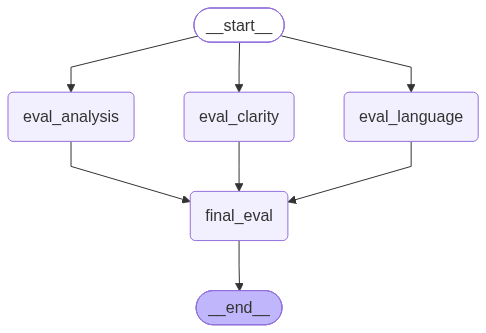

In [30]:
workflow